In [3]:
import pandas as pd
import numpy as np

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
incidence_df = pd.read_excel("/content/drive/My Drive/Colab Notebooks/cases_rainfall_data/Incidence-Measles-DRC-2020-2023.xlsx")

In [6]:
incidence_df

,ID,NUM,PAYS,PROV,ZS,POP,NUMSEM,DEBUTSEM,MALADIE,TOTALCAS,TOTALDECES,LETAL,ATTAQ,RecStatus,UniqueKey,UniqueID
0,3596,RDCITUARW02,RDC,Ituri,Ariwara,84843.0,2,2020-01-06,ROUGEOLE,1,0,0.0,1.2,1.0,223.0,3
1,3605,RDCNKVBZA02,RDC,Nord-Kivu,Binza,168322.0,2,2020-01-06,ROUGEOLE,1,0,0.0,0.6,1.0,212.0,12
2,3606,RDCKCTBOK02,RDC,Kongo-Central,Boko-Kivulu,111501.0,2,2020-01-06,ROUGEOLE,1,0,0.0,0.9,1.0,2395.0,13
3,3618,RDCKCEBUN02,RDC,Kasaï-Central,Bunkonde,80745.0,2,2020-01-06,ROUGEOLE,1,0,0.0,1.2,1.0,199.0,26
4,312,RDCKWAKAH02,RDC,Kwango,Kahemba,286245.0,2,2020-01-06,ROUGEOLE,1,0,0.0,0.3,1.0,67.0,48
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13394,1102,RDCSKVMIT08,RDC,Sud-Kivu,Miti-Murhesa,145949.0,8,2023-02-20,ROUGEOLE,169,0,0.0,115.8,1.0,1580.0,13352
13395,1124,RDCNKVOIC08,RDC,Nord-Kivu,Oicha,318770.0,8,2023-02-20,ROUGEOLE,192,1,1.0,60.2,1.0,1796.0,13373
13396,1025,RDCSKVIDJ08,RDC,Sud-Kivu,Idjwi,166424.0,8,2023-02-20,ROUGEOLE,209,0,0.0,125.6,1.0,1558.0,13276
13397,1114,RDCNKVMWE08,RDC,Nord-Kivu,Mweso,237179.0,8,2023-02-20,ROUGEOLE,240,0,0.0,101.2,1.0,1836.0,13364


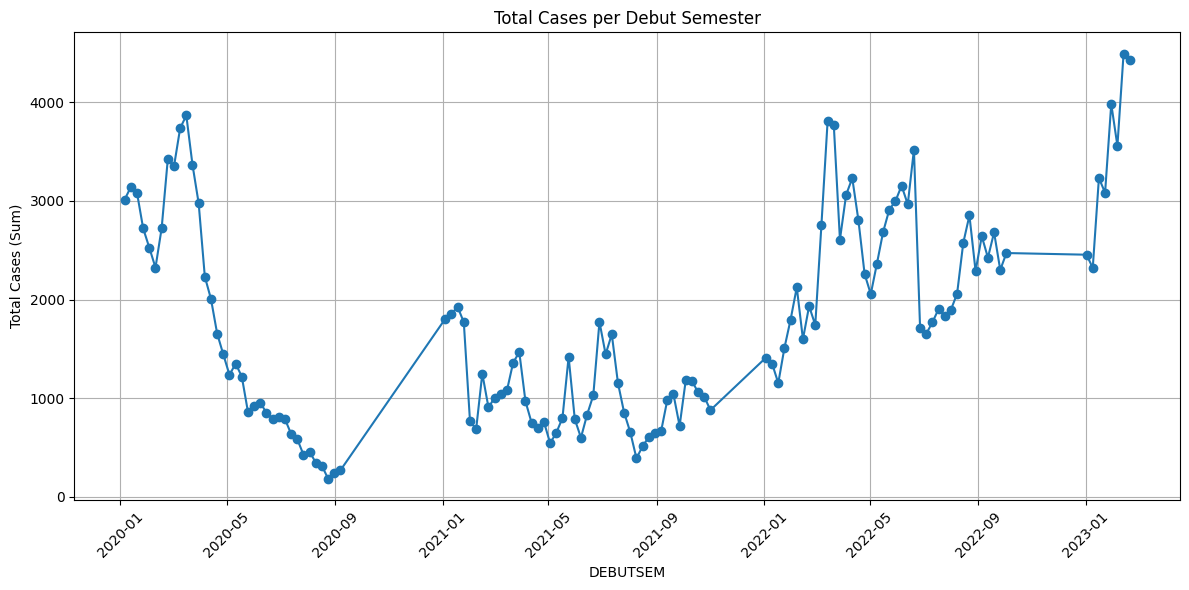

In [7]:
# prompt: plot a line graph of DEBUTSEM on x and TOTALCAS sum on y

import pandas as pd
import matplotlib.pyplot as plt

# Assuming incidence_df is already loaded as in the previous code

# Group by 'DEBUTSEM' and sum 'TOTALCAS'
grouped_data = incidence_df.groupby('DEBUTSEM')['TOTALCAS'].sum()

# Create the line plot
plt.figure(figsize=(12, 6))
plt.plot(grouped_data.index, grouped_data.values, marker='o')
plt.xlabel('DEBUTSEM')
plt.ylabel('Total Cases (Sum)')
plt.title('Total Cases per Debut Semester')
plt.grid(True)
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

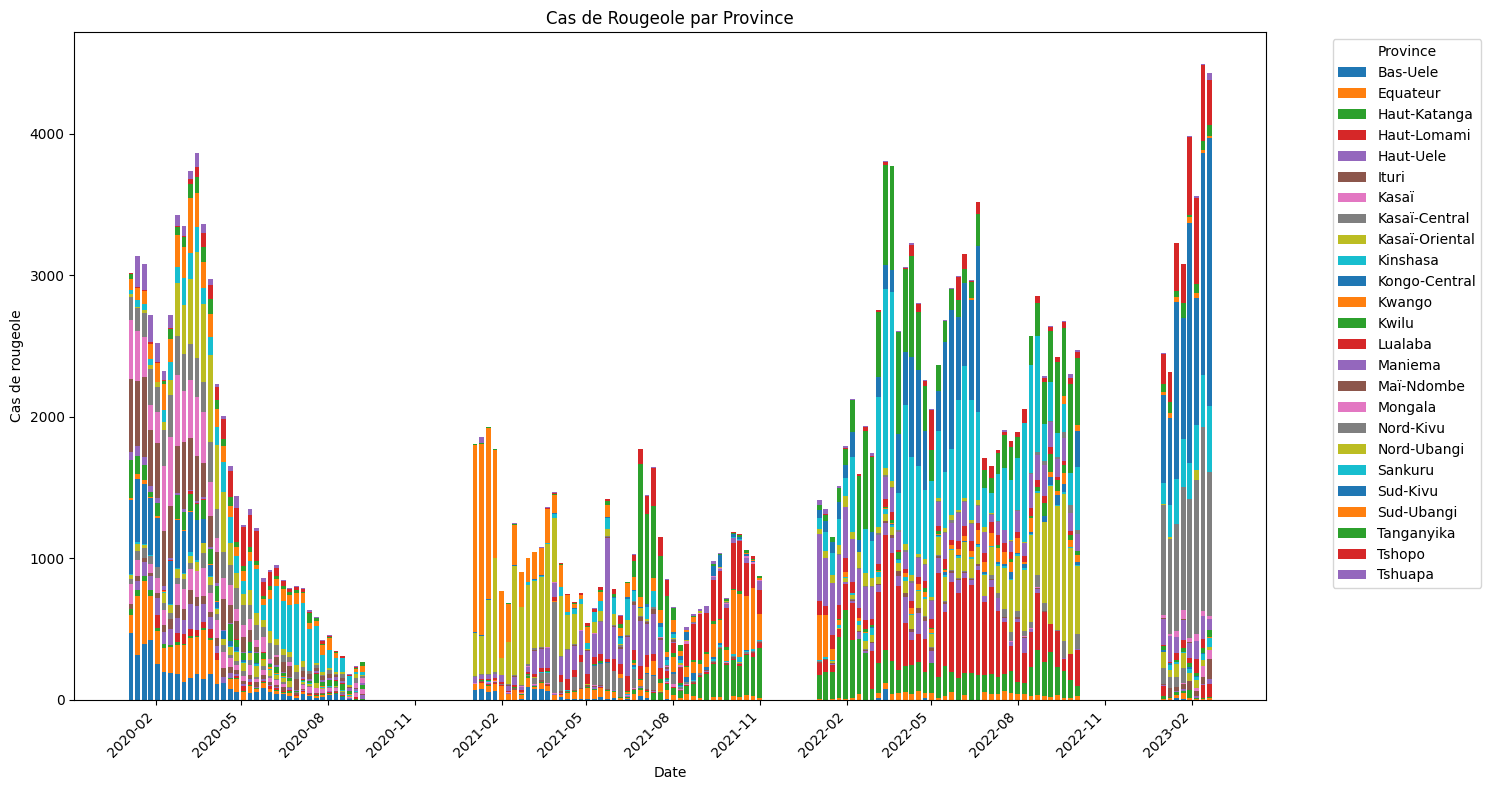

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Ensure 'DEBUTSEM' is in datetime format
incidence_df['DEBUTSEM'] = pd.to_datetime(incidence_df['DEBUTSEM'])

# Group data for plotting
grouped_data = incidence_df.groupby(['DEBUTSEM', 'PROV'])['TOTALCAS'].sum().unstack(fill_value=0)

# Ensure the index is in datetime format
grouped_data.index = pd.to_datetime(grouped_data.index)

# Create the plot
fig, ax = plt.subplots(figsize=(15, 8))  # Adjust figure size

# Plot as a stacked bar chart
for column in grouped_data.columns:
    ax.bar(grouped_data.index, grouped_data[column], label=column, width=5, bottom=grouped_data[grouped_data.columns[:list(grouped_data.columns).index(column)]].sum(axis=1))

# Format the x-axis to show only monthly ticks
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Major ticks every month
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))  # Format as Year-Month

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add labels and title
plt.xlabel("Date")
plt.ylabel("Cas de rougeole")
plt.title("Cas de Rougeole par Province")

# Position the legend outside the plot
plt.legend(title="Province", bbox_to_anchor=(1.05, 1), loc='upper left')

# Tight layout for better spacing
plt.tight_layout()

# Display the plot
plt.show()

<ipython-input-9-597bb5bc822e>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Province Group'] = ''
<ipython-input-9-597bb5bc822e>:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['DEBUTSEM'] = pd.to_datetime(filtered_df['DEBUTSEM'])


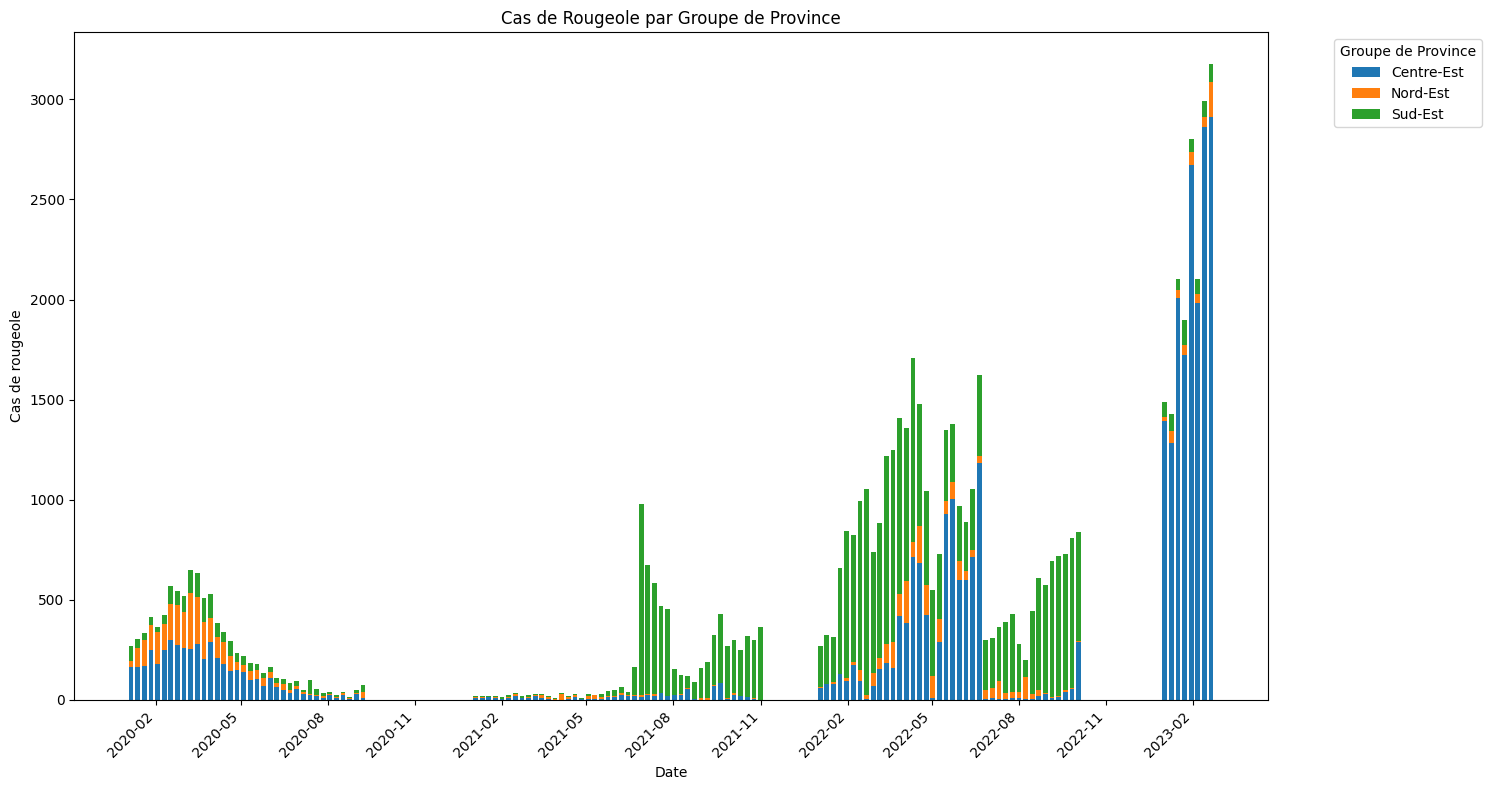

In [9]:
# prompt: plot the same graph but group cases by groups of provinces north-east = Haut-Uele, Ituri; Central-East = Nord-Kivu, Sud-Kivu; South-East = Tanganika, Haut Katanga; exclude all other data not in these provinces from the plot

# Define province groups
province_groups = {
    'Nord-Est': ['Haut-Uele', 'Ituri'],
    'Centre-Est': ['Nord-Kivu', 'Sud-Kivu'],
    'Sud-Est': ['Tanganyika', 'Haut-Katanga']
}

# Filter data to include only specified provinces
filtered_df = incidence_df[incidence_df['PROV'].isin(sum(province_groups.values(), []))]

# Create a new column for province groups
filtered_df['Province Group'] = ''
for group, provinces in province_groups.items():
    filtered_df.loc[filtered_df['PROV'].isin(provinces), 'Province Group'] = group

# Ensure 'DEBUTSEM' is in datetime format
filtered_df['DEBUTSEM'] = pd.to_datetime(filtered_df['DEBUTSEM'])

# Group data for plotting
grouped_data = filtered_df.groupby(['DEBUTSEM', 'Province Group'])['TOTALCAS'].sum().unstack(fill_value=0)

# Create the plot
fig, ax = plt.subplots(figsize=(15, 8))

# Plot as a stacked bar chart
for column in grouped_data.columns:
    ax.bar(grouped_data.index, grouped_data[column], label=column, width=5, bottom=grouped_data[grouped_data.columns[:list(grouped_data.columns).index(column)]].sum(axis=1))

# Format x-axis
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')

# Labels and title
plt.xlabel("Date")
plt.ylabel("Cas de rougeole")
plt.title("Cas de Rougeole par Groupe de Province")

# Legend
plt.legend(title="Groupe de Province", bbox_to_anchor=(1.05, 1), loc='upper left')

# Tight layout
plt.tight_layout()

# Display plot
plt.show()

<ipython-input-10-a2b138bd59b7>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['DEBUTSEM'] = pd.to_datetime(filtered_df['DEBUTSEM'])


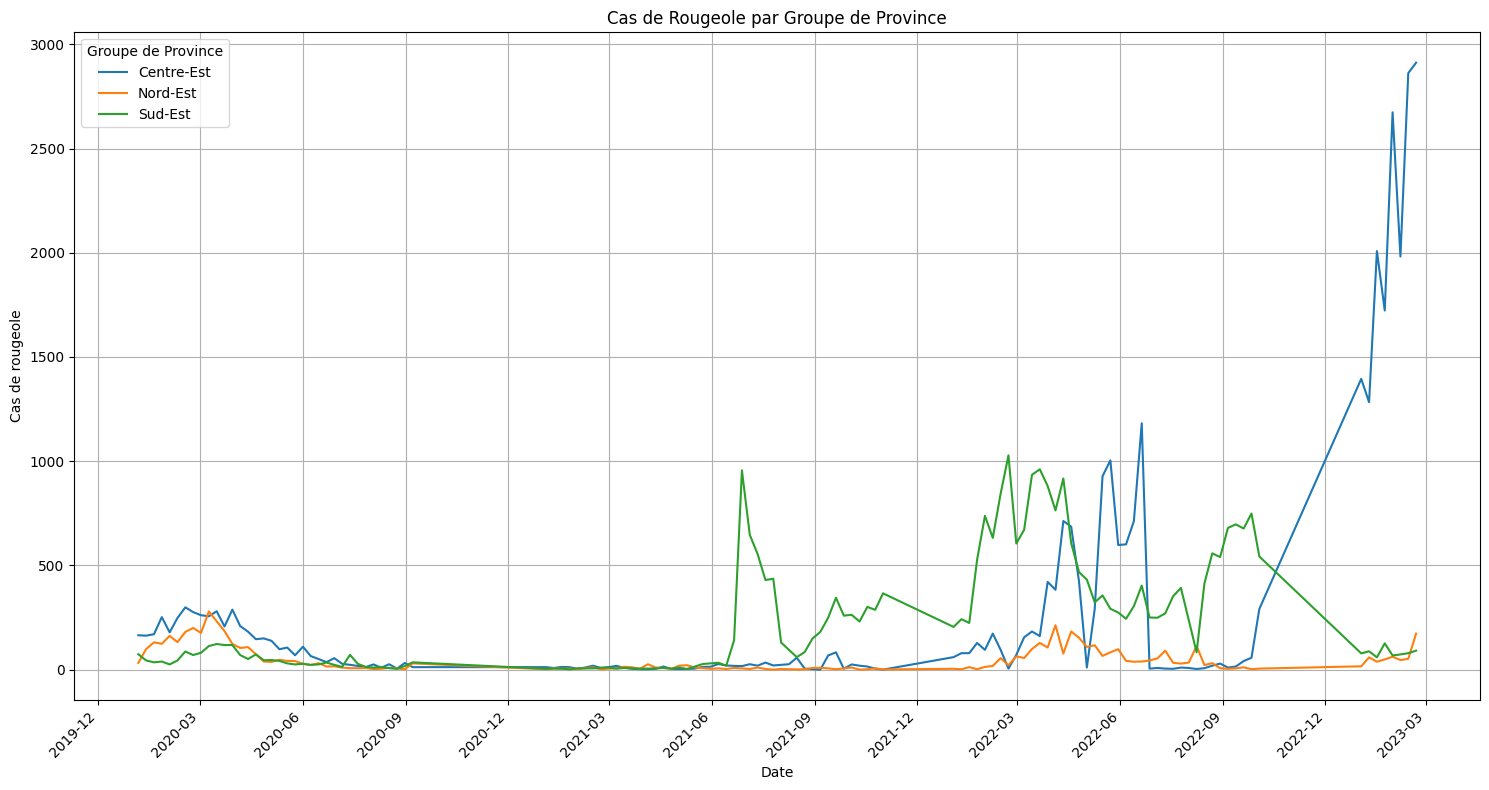

In [10]:
# prompt: make a line graph version on the previous graph wiht the province categories

# Assuming incidence_df and province_groups are defined as in the previous code

# Ensure 'DEBUTSEM' is in datetime format
filtered_df['DEBUTSEM'] = pd.to_datetime(filtered_df['DEBUTSEM'])

# Group data for plotting
grouped_data = filtered_df.groupby(['DEBUTSEM', 'Province Group'])['TOTALCAS'].sum().unstack(fill_value=0)

# Create the plot
plt.figure(figsize=(15, 8))

# Plot each province group as a line
for column in grouped_data.columns:
    plt.plot(grouped_data.index, grouped_data[column], label=column)

# Format x-axis
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45, ha='right')

# Labels and title
plt.xlabel("Date")
plt.ylabel("Cas de rougeole")
plt.title("Cas de Rougeole par Groupe de Province")

# Legend
plt.legend(title="Groupe de Province")

# Grid for better readability
plt.grid(True)

# Tight layout
plt.tight_layout()

# Display plot
plt.show()